In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
if not os.path.exists('/content/STATUN3106-image-memorability'):
    !git clone https://github.com/beccangruenberg/STATUN3106-image-memorability.git /content/STATUN3106-image-memorability
else:
    !git -C /content/STATUN3106-image-memorability pull

# ── SET YOUR DATA PATH HERE ────────────────────────────────
DATA_PATH = "/content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3104_Final_Project"
print(f"Data path set to: {DATA_PATH}")

!pip install -r /content/STATUN3106-image-memorability/requirements.txt                     

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
Data path set to: /content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/STATUN3104_Final_Project


                  image_path  memorability_score
0  lamem_subset/00000194.jpg            0.736842
1  lamem_subset/00000198.jpg            0.743590
2  lamem_subset/00000322.jpg            0.880000
3  lamem_subset/00000599.jpg            0.583333
4  lamem_subset/00000606.jpg            0.583333
Dataset size: 500


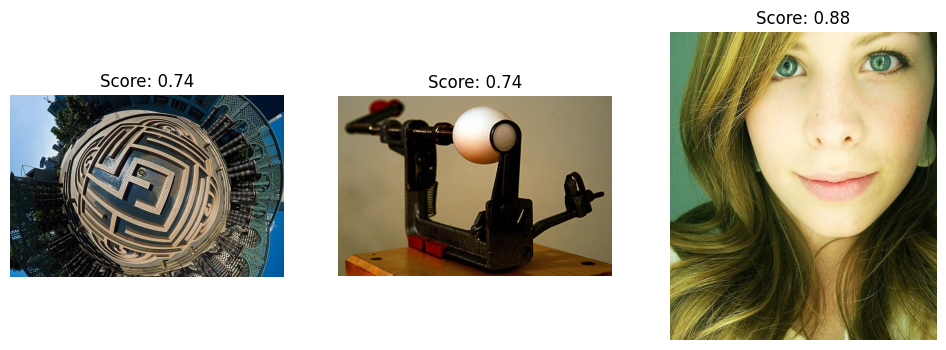

In [2]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt


df = pd.read_csv(f'{DATA_PATH}/data/lamem_prototype_images/image_list_with_scores.csv')
print(df.head())
print(f"Dataset size: {len(df)}")

# Sanity check: show a few images with their scores
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    img = Image.open(f"{DATA_PATH}/data/lamem_prototype_images/{df.iloc[i]['image_path']}")
    ax.imshow(img)
    ax.set_title(f"Score: {df.iloc[i]['memorability_score']:.2f}")
    ax.axis('off')
plt.show()

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

class LaMemDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(f"{self.img_dir}/{self.df.iloc[idx]['image_path']}").convert('RGB')
        score = torch.tensor(self.df.iloc[idx]['memorability_score'], dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, score

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img_dir = f"{DATA_PATH}/data/lamem_prototype_images/"


train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_loader = DataLoader(LaMemDataset(train_df, img_dir, transform), batch_size=32, shuffle=True)
val_loader = DataLoader(LaMemDataset(val_df, img_dir, transform), batch_size=32)

print(f"Train: {len(train_df)}, Val: {len(val_df)}")

Train: 400, Val: 100


In [4]:
import torch.nn as nn
import timm

class MemorabilityModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('resnet50', pretrained=True, num_classes=0)
        self.regressor = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.regressor(features).squeeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MemorabilityModel().to(device)
print(f"Running on: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Running on: cuda


In [5]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for imgs, scores in loader:
        imgs, scores = imgs.to(device), scores.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, scores)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def val_epoch(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, scores in loader:
            imgs, scores = imgs.to(device), scores.to(device)
            preds = model(imgs)
            total_loss += criterion(preds, scores).item()
    return total_loss / len(loader)

# Running 3 epochs only for demonstration
for epoch in range(3):
    train_loss = train_epoch(model, train_loader)
    val_loss = val_epoch(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1 | Train Loss: 0.0416 | Val Loss: 0.0301
Epoch 2 | Train Loss: 0.0172 | Val Loss: 0.0156
Epoch 3 | Train Loss: 0.0138 | Val Loss: 0.0133


In [ ]:
from datetime import datetime
timestamp = datetime.now().strftime("%m%d%y_%H%M%S")
torch.save(model.state_dict(), f'{DATA_PATH}/checkpoints/{timestamp}_model_epoch3.pth')
print(f"Saved: {timestamp}_model_epoch3.pth")

Saved: 033026_220225_model_epoch3.pth
